/var/folders/s2/nry612l527j2xxdsq0_70h6m0000gn/T/ipykernel_56376/3473190419.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [S]


/Users/elizabethmurphy/miniconda3/envs/SRTI/lib/python3.13/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


Text(0.5, 0, 'Days before detection')

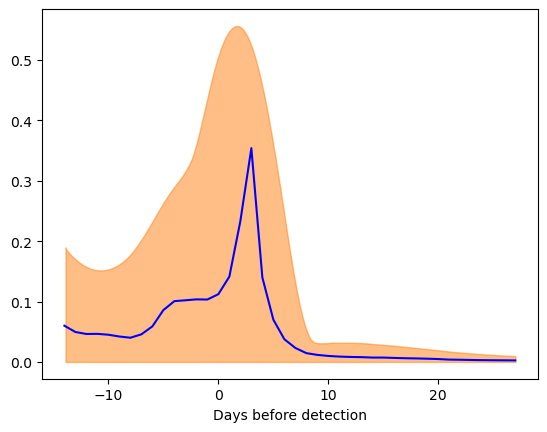

In [111]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd 
import pickle
import json
# import requests
from scipy import signal
from datetime import date,timedelta
# import yaml
import copy

import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

start = pd.to_datetime('2023-01-01')
eval_dates = [start + datetime.timedelta(days=7*j) for j in range(0,52)]


# option 2: use SD county data, resolved by catchment. 
cases = pd.read_csv('/Users/elizabethmurphy/Downloads/cases.csv',index_col=0)
cases = cases[cases['catchment'] =='PointLoma']
cases = cases[(cases.index>='2021-04-01') & (cases.index<='2022-07-01')]
cases.index = pd.to_datetime(cases.index)
cases = cases.groupby(pd.Grouper(freq='D'))[['new_cases']].sum()
cases['cases'] = cases['new_cases'].rolling(window=7, center=True, min_periods=0).mean()
ww_dict = {'Point Loma':['/Users/elizabethmurphy/Downloads/PointLoma_sewage_seqs.csv','/Users/elizabethmurphy/Downloads/PointLoma_sewage_qPCR.csv']}
for site, files in zip(ww_dict.keys(),ww_dict.values()):
    df = pd.read_csv(f'{files[0]}')

    df['Date'] = pd.to_datetime(df['Date'])
    df.columns = [dfc.split(' (')[0] for dfc in df.columns]
    df =df.set_index('Date')
    df = df[df.index>='2021-04-01']
    df = df[df.index<='2022-07-01']
    df = df.dropna(axis = 0, how = 'all')
    df = df.fillna(0)
    df = df/100.

    df = df.drop(columns=['Other'])
    df = df[df.columns[df.sum(axis=0) > 0.01]]

    cdf = pd.read_csv(f'{files[1]}')
    cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
    cdf =cdf.set_index('Sample_Date')

    cdf = cdf.resample('D').asfreq()
    cdf = cdf.rolling(window=7, center=True, min_periods=0).mean()
    sharedInds = np.sort(list(set(cdf.index) & set(cases.index)))
    cdf = cdf.loc[sharedInds]



minInd = np.max([cdf.index.min(),cases.index.min()])
maxInd = np.min([cdf.index.max(),cases.index.max()])

cdf = cdf[cdf.index>=minInd]
cdf = cdf[cdf.index<=maxInd]

cases = cases[cases.index>=minInd]
cases = cases[cases.index<=maxInd]

cdf = pd.concat([cdf,cases],axis=1)
cdf = cdf.dropna(how='any')

N = 42
F = 14
X = np.array([cdf['cases'].values[(j-F):(j+N-F)] for j in range(F,(cdf.shape[0]-N+F))])#/cdf['cases'].mean()
Y = np.array(cdf['Mean viral gene copies/L'].values[F:(len(cdf['Mean viral gene copies/L'])-N+F)])/cdf['Mean viral gene copies/L'].mean()


with pm.Model() as shedding_model:
    S = pm.HalfFlat("S",shape=N)
    mu = pm.math.dot(X, S)
    Y_obs = pm.Gamma("Y_obs", alpha = mu/50, beta=50, observed=Y)
    trace = pm.sample(1000, return_inferencedata=True)


lags = np.arange(N) - F
fig,ax = plt.subplots()
az.plot_hdi(lags, trace.posterior["S"].values, hdi_prob=0.95,ax=ax)
ax.plot(lags, np.median(trace.posterior["S"].values,axis=(0,1)), color="blue")
ax.set_xlabel("Days before detection")

(array([18748., 18809., 18871., 18932., 18993., 19052., 19113.]),
 [Text(18748.0, 0, '2021-05'),
  Text(18809.0, 0, '2021-07'),
  Text(18871.0, 0, '2021-09'),
  Text(18932.0, 0, '2021-11'),
  Text(18993.0, 0, '2022-01'),
  Text(19052.0, 0, '2022-03'),
  Text(19113.0, 0, '2022-05')])

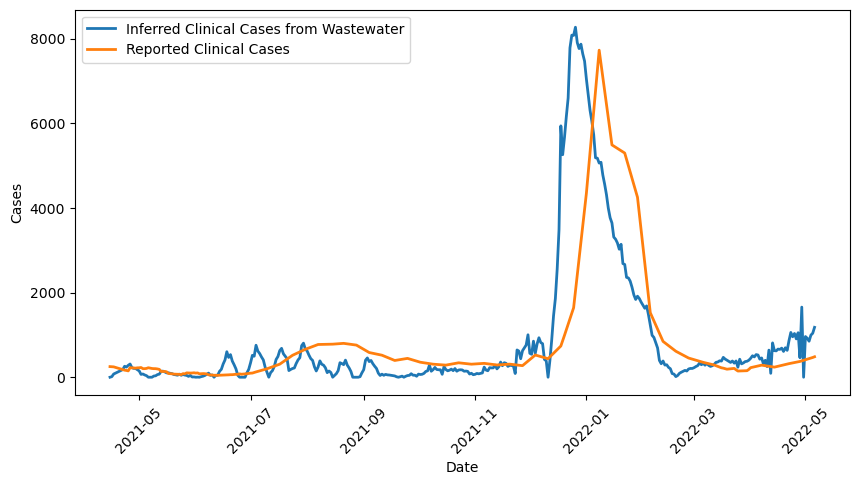

In [ ]:
from numpy.fft import fft, ifft

S = np.median(trace.posterior["S"].values, axis=(0, 1))
S = S / S.sum()

VL = cdf['Mean viral gene copies/L'].rolling(window=7, center=True, min_periods=0).mean()
VL = VL[F:(len(VL)-N+F)]
VL = VL / np.mean(VL) * np.mean(Y)

def inverse(VL, S):
    length = len(VL) - len(S)
    S_pad = np.pad(S, (0, length), mode='constant')
    VL_fft = fft(VL)
    S_fft = fft(S_pad)
    H = S_fft
    H_T = np.conj(H)
    y = VL_fft
    C = (H_T * y) / (H_T * H)

    C = np.real(ifft(C))
    C[C < 0] = 0
    return C

C = inverse(VL, S)

reported = cdf['cases'].values[F:(len(cdf['cases'])-N+F)]
C_rescaled = C * (np.mean(reported) / np.mean(C))
C_rescaled = C_rescaled[:-28]

C_dates = cdf.index[F:(len(cdf.index)-N+F)]
C_dates_inv = C_dates[:len(C_rescaled)]

plt.figure(figsize=(10, 5))
plt.plot(C_dates_inv, C_rescaled, label='Inferred Clinical Cases from Wastewater', linewidth=2)
plt.plot(C_dates_inv, reported[:len(C_rescaled)], label='Reported Clinical Cases', linewidth=2)
plt.legend()
plt.xlabel('Date')
plt.ylabel('Cases')

In [113]:
import pandas as pd
import numpy as np
from scipy.stats import gamma, poisson

import epyestim
import epyestim.covid19 as covid19

ch_cases = pd.Series(C[:-28], index=C_dates_inv).round().astype(int)

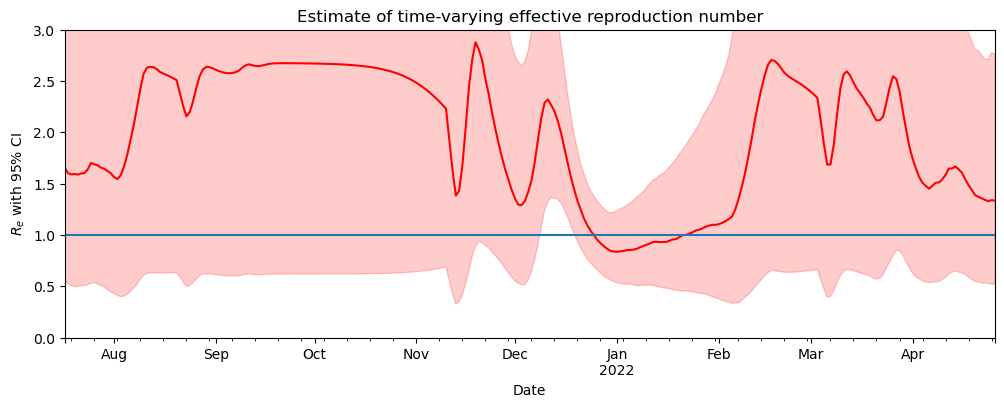

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-04-22,1.0,1.439277,0.318624,0.530489,1.356254,2.752466
2022-04-23,1.0,1.418717,0.328869,0.533279,1.340930,2.708423
2022-04-24,1.0,1.405774,0.329875,0.526347,1.327876,2.711059
2022-04-25,1.0,1.422710,0.332874,0.519541,1.337660,2.775527
2022-04-26,1.0,1.417011,0.330707,0.520520,1.334257,2.757365


In [114]:
ch_time_varying_r = covid19.r_covid(ch_cases)

ch_time_varying_r.tail()

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r.loc[:,'Q0.5'].plot(ax=ax, color='red')
ax.fill_between(ch_time_varying_r.index, 
                    ch_time_varying_r['Q0.025'], 
                    ch_time_varying_r['Q0.975'], 
                    color='red', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()

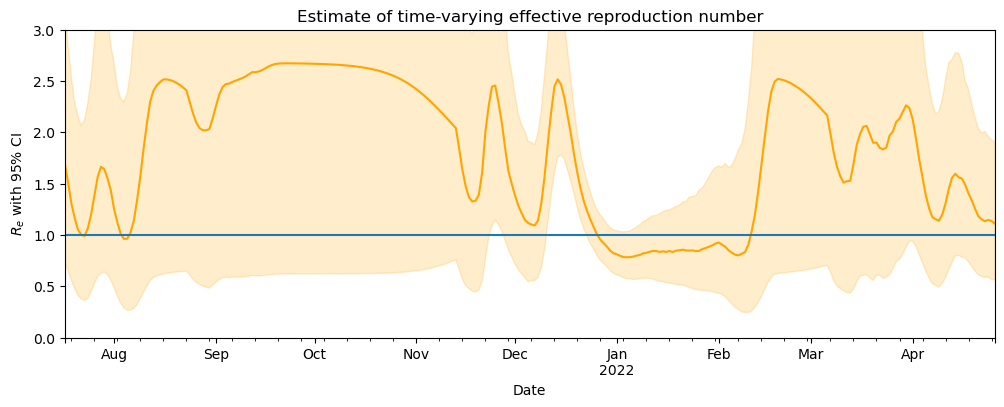

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-04-22,1.0,1.439277,0.318624,0.530489,1.356254,2.752466
2022-04-23,1.0,1.418717,0.328869,0.533279,1.340930,2.708423
2022-04-24,1.0,1.405774,0.329875,0.526347,1.327876,2.711059
2022-04-25,1.0,1.422710,0.332874,0.519541,1.337660,2.775527
2022-04-26,1.0,1.417011,0.330707,0.520520,1.334257,2.757365


In [115]:
ch_time_varying_r_ = covid19.r_covid(ch_cases, smoothing_window=14, r_window_size=7)

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r_.loc[:,'Q0.5'].plot(ax=ax, color='orange')
ax.fill_between(ch_time_varying_r_.index, 
                    ch_time_varying_r_['Q0.025'], 
                    ch_time_varying_r_['Q0.975'], 
                    color='orange', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()

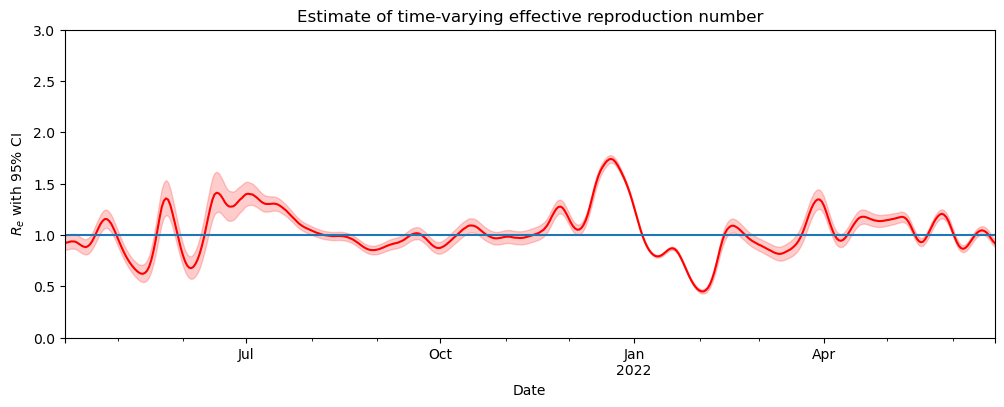

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-06-17,892.0,1.024168,0.000405,0.985228,1.024037,1.064034
2022-06-18,1024.0,1.002191,0.000392,0.963543,1.002059,1.041588
2022-06-19,1007.0,0.973135,0.000378,0.935482,0.973007,1.011455
2022-06-20,990.0,0.942285,0.000366,0.905198,0.942155,0.980272
2022-06-21,973.0,0.919424,0.000359,0.882529,0.919294,0.956808


In [116]:
# TEST ON CLINICAL DATA
reported_cases = pd.Series(cases['cases'].values, index=cases.index).round().astype(int)

ch_time_varying_r = covid19.r_covid(reported_cases)

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r.loc[:,'Q0.5'].plot(ax=ax, color='red')
ax.fill_between(ch_time_varying_r.index, 
                    ch_time_varying_r['Q0.025'], 
                    ch_time_varying_r['Q0.975'], 
                    color='red', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()